### Типы задач при работе с последовательностями

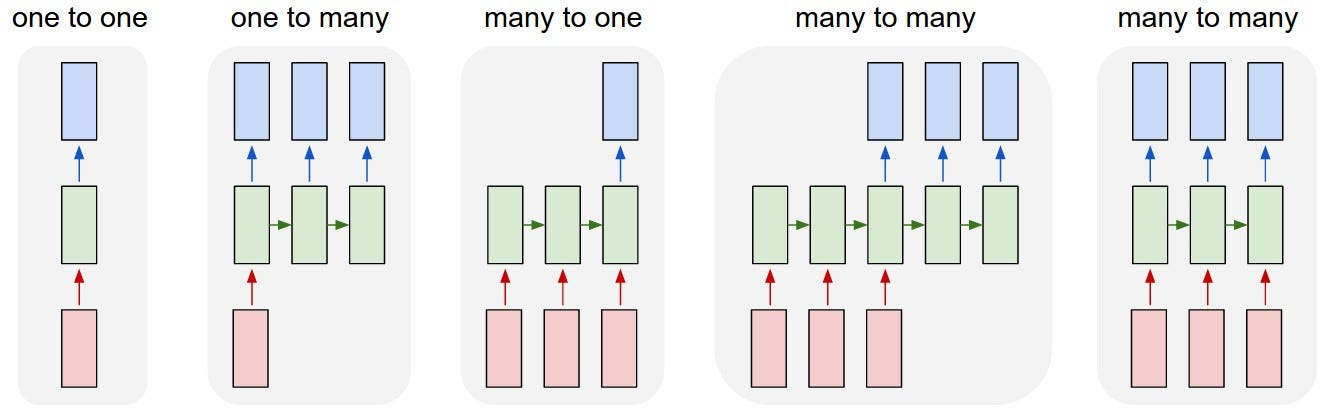



*  **One-to-one** - один вход и один выход. Это самый простой случай, под который подпадают такие задачи, как классификация изображений, где одно изображение соответствует одной метке.
*  **One-to-many** - один вход и несколько выходов. Пример задачи - генерация подписей для изображения.
* **Many-to-one** - типичный пример - классификация текстов.
* **Many-to-many** v1 - последовательности разной длины на входе и на выходе. Применяется в таких задачах, как машинный перевод, где предложение на одном языке переводится в предложение на другом языке, но, вероятно, с другим количеством токенов.
* **Many-to-many** v2 - последовательности одной длины на входе и на выходе. Применяется в таких задачах, как NER, POS-tagging, где каждому токену входа сопоставляется свой выход.



## Архитектура encoder-decoder для машинного перевода


![img](https://esciencegroup.files.wordpress.com/2016/03/seq2seq.jpg)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from nltk.tokenize import WordPunctTokenizer
from nltk.translate.bleu_score import corpus_bleu

from sklearn.model_selection import train_test_split
from vocab import Vocab

import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output
from tqdm import tqdm, trange

%matplotlib inline

## Машинный перевод

Попробуем решить задачу машинного перевода с русского на английский. В частности, будем работать с описаниями отелей.

Прежде чем перейти к  реализации архитектуры, необходимо выполнить некоторую предварительную обработку - токенизацию.

Данные содержат уникальные редкие слова. Если мы работаем на уровне слов, нам придется иметь дело с большим словарем. Если вместо этого мы будем использовать модели на уровне отдельных символов, для обработки последовательности потребуется много итераций. На этот раз мы выберем нечто среднее.

Один из популярных подходов называется [Byte Pair Encoding](https://github.com/rsennrich/subword-nmt) , также известный как BPE. Алгоритм начинается с токенизации на уровне символов, а затем итеративно объединяет наиболее часто встречающиеся пары в течение N итераций. Это приводит к тому, что часто встречающиеся слова объединяются в один токен, а редкие слова разбиваются на слоги или даже символы.




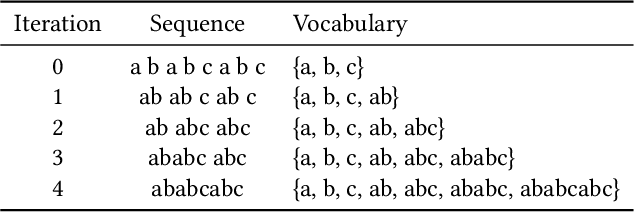

### Подгрузка данных

In [ ]:
!wget https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1 -O data.txt

--2025-03-06 20:49:09--  https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/mw8tdyetqboqwkn5ma886/data.txt?rlkey=t9fmsizx27ikh0vak0ir265a6&dl=1 [following]
--2025-03-06 20:49:09--  https://www.dropbox.com/scl/fi/mw8tdyetqboqwkn5ma886/data.txt?rlkey=t9fmsizx27ikh0vak0ir265a6&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucefced7de5f501dec4f65f0f50f.dl.dropboxusercontent.com/cd/0/inline/ClZ0PMyQg18jNoDpmH3cIjOSJ9jHbN1Th6YYROVg0BmYu0VAOyHa4T7PuUP0tjdtDn6McQIwm99XoQpxAYAPK5SetINbkvMmTU4C5FxPVLd1tBWceFFLzOfrgX9LUjaYAII/file?dl=1# [following]
--2025-03-06 20:49:09--  https://ucefced7de5f501dec4f65f0f50f.dl.dropboxusercontent.com/cd/0/inline/ClZ0PMyQg18

In [ ]:
with open('data.txt') as f:
  print(f.readlines()[0])

Cordelia Hotel is situated in Tbilisi, a 3-minute walk away from Saint Trinity Church.	Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора.



### BPE

[Subword Neural Machine Translation](https://github.com/rsennrich/subword-nmt) - Unsupervised Word Segmentation for Neural Machine Translation and Text Generation

In [ ]:
!pip install subword-nmt

In [ ]:
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE

In [ ]:
tokenizer = WordPunctTokenizer()

def tokenize(x):
  return ' '.join(tokenizer.tokenize(x.lower()))

In [ ]:
with open('train.en', 'w') as f_src,  open('train.ru', 'w') as f_dst:
  for line in open('data.txt'):
    src_line, dst_line = line.strip().split('\t')
    f_src.write(tokenize(src_line) + '\n')
    f_dst.write(tokenize(dst_line) + '\n')

In [ ]:
bpe = {}
for lang in ['en', 'ru']:
    learn_bpe(open('./train.' + lang), open('bpe_rules.' + lang, 'w'), num_symbols=8000)
    bpe[lang] = BPE(open('./bpe_rules.' + lang))

    with open('train.bpe.' + lang, 'w') as f_out:
        for line in open('train.' + lang):
            f_out.write(bpe[lang].process_line(line.strip()) + '\n')

100%|██████████| 8000/8000 [00:09<00:00, 817.55it/s]


### Построение словарей


In [ ]:
data_inp = np.array(open('./train.bpe.ru').read().split('\n'))
data_out = np.array(open('./train.bpe.en').read().split('\n'))

train_inp, dev_inp, train_out, dev_out = train_test_split(
    data_inp,
    data_out,
    test_size=3000,
    random_state=2023,
)

for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

inp: этот отель находится в центре парижа , в 2 минутах от площади республики и станции метро с 5 лини@@ ями метро и 4 автобус@@ ными маршру@@ тами .
out: this hotel is located in the centre of paris , 2 minutes from place de la ré@@ pub@@ li@@ que and its metro station , which offers 5 metro lines and 4 bus lines .

inp: на полностью оборудованной мини - кухне можно самостоятельно готовить .
out: there is a full kitchenette where guests are welcome to prepare their meals .

inp: номера находятся под кры@@ шей или на ниж@@ них эта@@ жах с эр@@ ке@@ рами с видом на сад .
out: set under the roof or on the lower floors with bay windows looking out onto the park , they are all equipped with wi - fi access .



In [ ]:
inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

In [ ]:
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = inp_voc.to_matrix(batch_lines)
batch_lines_restored = inp_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)
print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)
print("\nback to words")
print(batch_lines_restored)

lines
['гостевой дом r .', 'имеется балкон .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .']

words to ids (0 = bos, 1 = eos):
tensor([[   0, 2688, 2943, 1109,   29,    1,    1,    1],
        [   0, 3486, 1869,   29,    1,    1,    1,    1],
        [   0, 2922, 1833, 8034,   59, 3799,   29,    1],
        [   0, 6028, 2083,   29,    1,    1,    1,    1],
        [   0, 4927, 1869,   29,    1,    1,    1,    1]])

back to words
['гостевой дом r .', 'имеется балкон .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .']


Распределения длин исходных текстов и переводов

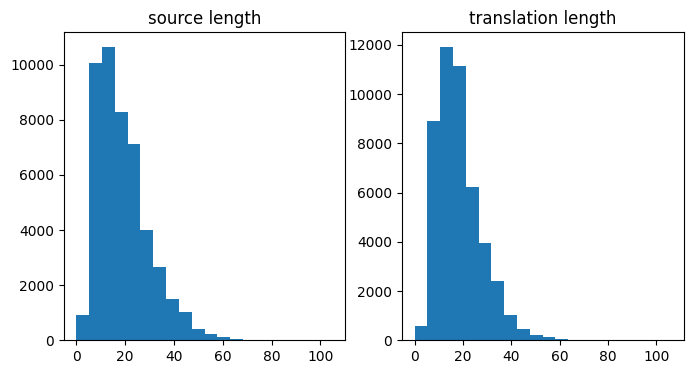

In [ ]:
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(map(len, map(str.split, train_inp))), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(map(len, map(str.split, train_out))), bins=20);

### Encoder-decoder model


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

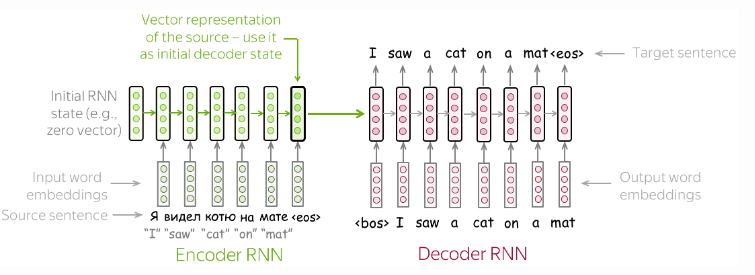

In [ ]:
class BasicModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__()

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """ Apply model in training mode """
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)


    def encode(self, inp, **flags):
        """
        Takes input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :returns: initial decoder state tensors, one or many
        """
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]

        enc_seq, last_state_but_not_really = self.enc0(inp_emb)
        # enc_seq: [batch, sequence length, hid_size], last_state: [batch, hid_size]

        # note: last_state is not _actually_ last because of padding, let's find the real last_state
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors, same as returned by encode(...)
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, len(out_voc)]
        """
        prev_gru0_state = prev_state[0]
        prev_emb = self.emb_out(prev_tokens)
        new_dec_state = self.dec0(prev_emb, prev_gru0_state) # input & hidden states
        output_logits = self.logits(new_dec_state)

        return [new_dec_state], output_logits

    def decode(self, initial_state, out_tokens, **flags):
        """ Iterate over reference tokens (out_tokens) with decode_step """
        batch_size = out_tokens.shape[0]
        state = initial_state

        # initial logits: always predict BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Generate translations from model (greedy version) """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states


In [ ]:
model = BasicModel(inp_voc, out_voc).to(device)

dummy_inp_tokens = inp_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = out_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list) and len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(out_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(out_voc))

# full forward
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [ ]:
train_inp[:3]

array(['этот отель находится в центре парижа , в 2 минутах от площади республики и станции метро с 5 лини@@ ями метро и 4 автобус@@ ными маршру@@ тами .',
       'на полностью оборудованной мини - кухне можно самостоятельно готовить .',
       'номера находятся под кры@@ шей или на ниж@@ них эта@@ жах с эр@@ ке@@ рами с видом на сад .'],
      dtype='<U524')

In [ ]:
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)
print("Translations without training:")
print('\n'.join([line for line in dummy_translations]))

Translations without training:
tor@@ β@@ tram@@ cabañas mogren rurales rurales dryer án naz@@ vets they suites cool@@ liber@@ novo kitchenware requests yaroslav@@ with cos@@ splash cab@@ campo@@ closed
tor@@ vard rhine lighthouse thor@@ net@@ requests yaroslav@@ with cos@@ splash cab@@ campo@@ closed summer aces activ@@ tia insky security into em fels midi harmo@@
mine bor bello course ements noi fa@@ campo@@ ver@@ simp@@ fa@@ during paphos hagen volleyball thor@@ net@@ pick requests yaroslav@@ bak@@ guided recre@@ rainforest erno


### Loss

Будем минимизировать categorical crossentropy во время обучения на данных $D$:
$$ L = {\frac1{|D|}} \sum_{X, Y \in D} \sum_{y_t \in Y} - \log p(y_t \mid y_1, \dots, y_{t-1}, X, \theta) $$

$|D|$ - длина всех последовательностей, включая BOS and первые EOS токены, кроме PAD

In [ ]:
def compute_loss(model, inp, out, **flags):
    """
    Compute loss (float32 scalar) as in the formula above
    :param inp: input tokens matrix, int32[batch, time]
    :param out: reference tokens matrix, int32[batch, time]

    In order to pass the tests, your function should
    * include loss at first EOS but not the subsequent ones
    * divide sum of losses by a sum of input lengths (use voc.compute_mask)
    """
    mask = model.out_voc.compute_mask(out) # [batch_size, out_len]
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)

    # outputs of the model, [batch_size, out_len, num_tokens]
    logits_seq = model(inp, out)

    # log-probabilities of all tokens at all steps, [batch_size, out_len, num_tokens]
    logprobs_seq = torch.log_softmax(logits_seq, dim=-1)

    # log-probabilities of correct outputs, [batch_size, out_len]
    logp_out = (logprobs_seq * targets_1hot).sum(dim=-1)
    # ^-- this will select the probability of the actual next token.
    # Note: you can compute loss more efficiently using using F.cross_entropy

    # average cross-entropy over tokens where mask == True
    return -logp_out[mask].mean()

In [ ]:
dummy_loss = compute_loss(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)
assert np.allclose(dummy_loss.item(), 7.5, rtol=0.1, atol=0.1), "We're sorry for your loss"

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

Loss: tensor(7.5533, device='cuda:0', grad_fn=<NegBackward0>)


### Оценка качества: BLEU

Распространенная матрика машинного перевода - [BLEU](https://en.wikipedia.org/wiki/BLEU). Эта метрика вычисляет долю верно предсказанных n-grams. В частности, например, для n=1, 2, 3, 4 она вычисляется как геометрическое среднее со штрафом за короткие переводы.

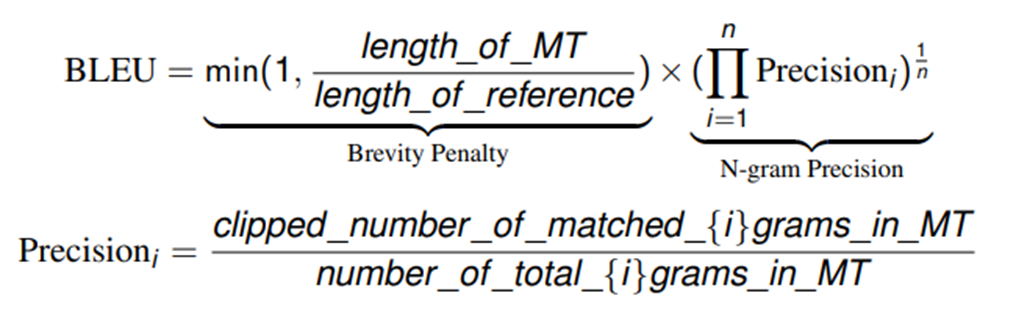

[Эволюция метрик качества машинного перевода](https://habr.com/ru/articles/745642/)

In [ ]:
def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    """
    Estimates corpora-level BLEU score of model's translations given inp and reference out
    """
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
        ) * 100

In [ ]:
compute_bleu(model, dev_inp, dev_out)

0.00223519492972634

### Training loop

Training encoder-decoder models isn't that different from any other models: sample batches, compute loss, backprop and update

In [ ]:
metrics = {'train_loss': [], 'dev_bleu': [] }

model = BasicModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

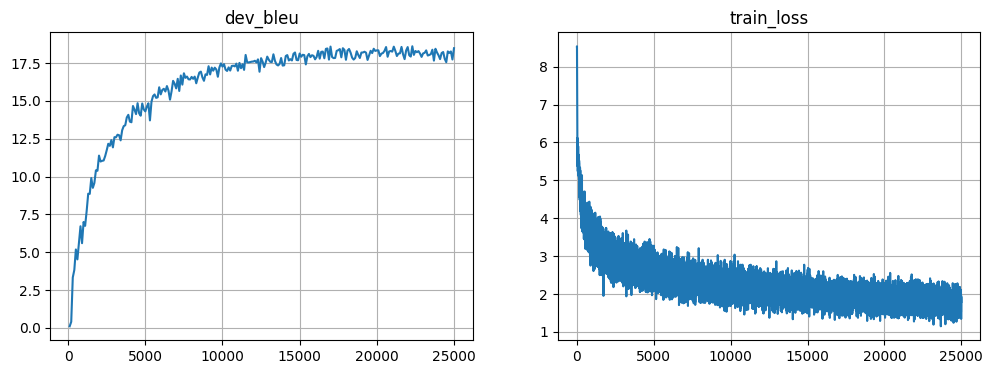

Mean loss=1.734


100%|██████████| 25000/25000 [19:51<00:00, 20.98it/s]


In [ ]:
for _ in trange(25000):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    opt.zero_grad()
    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    opt.step()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

# Note: it's okay if bleu oscillates up and down as long as it gets better on average over long term (e.g. 5k batches)

In [ ]:
assert np.mean(metrics['dev_bleu'][-10:], axis=0)[1] > 15, "We kind of need a higher bleu BLEU from you. Kind of right now."

In [ ]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в ванной комнате с ванной предоставляется фен .
featuring a bath , the bathroom also comes with a bath .

на территории можно сыграть в дартс и сквош .
other facilities offered at the property include a games room , a dry cleaning and a billiards table .

апартаменты располагают гостиной зоной .
the apartment will provide you with a seating area .

гости могут самостоятельно приготовить блюда на полностью укомплектованной кухне .
guests are fully equipped with a fully equipped kitchen and a coffee machine .

к услугам гостей 2 спальни и 1 ванная комната с ванной и / или душем , а также кухня с духовкой и микроволновой печью .
the apartment will provide you with a tv and a bathroom with a bath or a bath or a bath or a bath or a microwave .

ужин для гостей приготовят в ресторане ron@@ ni@@ e ' s w@@ ing@@ s & o@@ y@@ st@@ er bar .
guests can enjoy a drink at the on - site restaurant bar , which is open 24 - hours a day .



In [ ]:
compute_bleu(model, dev_inp, dev_out)

18.48366063575341

### Attention

Добавим простой attention:

Имея последовательность $ h^e_0, h^e_1, h^e_2, ..., h^e_T$ из encoder'а и decoder state $h^d$,

* Вычислим логиты двухслойной сеткой
$$a_t = linear_{out}(tanh(linear_{e}(h^e_t) + linear_{d}(h_d)))$$
* Получим вероятности,
$$ p_t = {{e ^ {a_t}} \over { \sum_\tau e^{a_\tau} }} $$

* Взвесим состояния encoder'а с вероятностями, чтобы получить **attention**
$$ attn = \sum_t p_t \cdot h^e_t $$

[Attention and Augmented Recurrent Neural Networks](https://distill.pub/2016/augmented-rnns/).

In [ ]:
class AttentionLayer(nn.Module):
    def __init__(self, enc_size, dec_size, hid_size):
        """ A layer that computes additive attention response and weights """
        super().__init__()
        self.enc_size = enc_size # num units in encoder state
        self.dec_size = dec_size # num units in decoder state
        self.hid_size = hid_size # attention layer hidden units

        self.linear_enc = nn.Linear(enc_size, hid_size)
        self.linear_dec = nn.Linear(dec_size, hid_size)
        self.linear_out = nn.Linear(hid_size, 1)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, enc, dec, inp_mask):
        """
        Computes attention response and weights
        :param enc: encoder activation sequence, float32[batch_size, ninp, enc_size]
        :param dec: single decoder state used as "query", float32[batch_size, dec_size]
        :param inp_mask: mask on enc activatons (0 after first eos), float32 [batch_size, ninp]
        :returns: attn[batch_size, enc_size], probs[batch_size, ninp]
            - attn - attention response vector (weighted sum of enc)
            - probs - attention weights after softmax
        """
        batch_size, ninp, enc_size = enc.shape

        # Compute logits
        x = self.linear_dec(dec).reshape(-1, 1, self.hid_size)
        x = torch.tanh(self.linear_enc(enc) + x)
        x = self.linear_out(x)

        # Apply mask - if mask is 0, logits should be -inf or -1e9
        # You may need torch.where
        x[torch.where(inp_mask == False)] = -1e9

        # Compute attention probabilities (softmax)
        probs = self.softmax(x.reshape(batch_size, ninp))

        # Compute attention response using enc and probs
        attn = (probs.reshape(batch_size, ninp, 1) * enc).sum(1)

        return attn, probs

### Seq2seq model + attention

Теперь можно использовать слой attention в Seq2Seq модели:
![img](https://i.imgur.com/6fKHlHb.png)
_image from distill.pub [article](https://distill.pub/2016/augmented-rnns/)_

На каждом шагу используем предыдущее состояние декодера для подсчета attention, затем приконкатенируем attention ко входам следующего слоя. T


In [ ]:
class AttentiveModel(BasicModel):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128, attn_size=128):
        """ Translation model that uses attention. See instructions above. """
        super().__init__(inp_voc, out_voc, emb_size, hid_size)
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.enc0 = nn.LSTM(emb_size, hid_size, num_layers=2, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)

        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.attention = AttentionLayer(hid_size, hid_size, attn_size)


    def encode(self, inp, **flags):
        """
        Takes input sequences, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """
        # encode input sequence, create initial decoder states
        inp_emb = self.emb_inp(inp)
        enc_seq, last_state_but_not_really = self.enc0(inp_emb)
        #[dec_start] = super().encode(inp, **flags)

        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]
        dec_start = self.dec_start(last_state)

        # apply attention layer from initial decoder hidden state
        inp_mask = self.out_voc.compute_mask(inp)
        first_attn_probas = self.attention(enc_seq, dec_start, inp_mask)

        # Build first state: include
        # * initial states for decoder recurrent layers
        # * encoder sequence and encoder attn mask (for attention)
        # * make sure that last state item is attention probabilities tensor

        first_state = [dec_start, enc_seq, inp_mask, first_attn_probas]
        return first_state

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, n_tokens]
        """

        prev_gru0_state, enc_seq, enc_mask, _ = prev_state
        attn, attn_probs = self.attention(enc_seq, prev_gru0_state, enc_mask)

        x = self.emb_out(prev_tokens)
        x = torch.cat([attn, x], dim=-1)
        x = self.dec0(x, prev_gru0_state)

        new_dec_state = [x, enc_seq, enc_mask, attn_probs]
        output_logits = self.logits(x)
        return [new_dec_state, output_logits]


### Training loop - модель с Attention


In [ ]:
metrics = {'train_loss': [], 'dev_bleu': [] }

model = AttentiveModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

In [ ]:
model

AttentiveModel(
  (emb_inp): Embedding(8047, 64)
  (emb_out): Embedding(7800, 64)
  (enc0): LSTM(64, 128, num_layers=2, batch_first=True)
  (dec_start): Linear(in_features=128, out_features=128, bias=True)
  (dec0): GRUCell(192, 128)
  (logits): Linear(in_features=128, out_features=7800, bias=True)
  (attention): AttentionLayer(
    (linear_enc): Linear(in_features=128, out_features=128, bias=True)
    (linear_dec): Linear(in_features=128, out_features=128, bias=True)
    (linear_out): Linear(in_features=128, out_features=1, bias=True)
    (softmax): Softmax(dim=-1)
  )
)

In [ ]:
compute_bleu(model, dev_inp, dev_out)

0.0020633142012208075

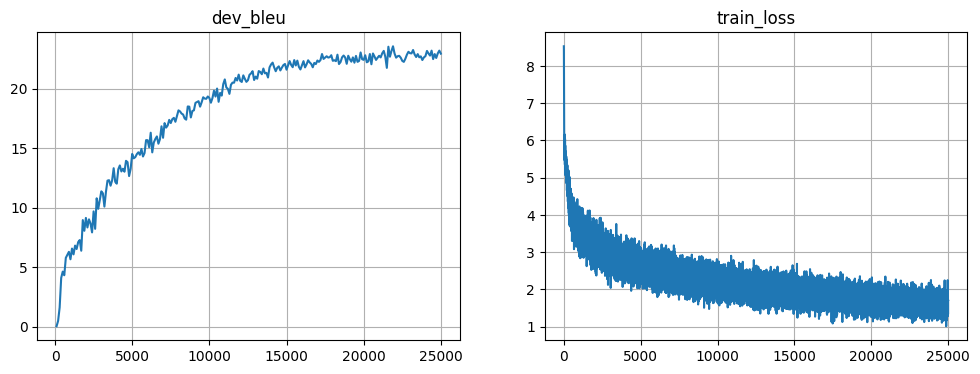

Mean loss=1.585


100%|██████████| 25000/25000 [53:46<00:00,  7.75it/s]


In [ ]:
for _ in trange(25000):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    opt.zero_grad()
    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    opt.step()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)


In [ ]:
compute_bleu(model, dev_inp, dev_out)

22.966888722528044

In [ ]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в ванной комнате с ванной предоставляется фен .
the bathroom comes with a bathtub and a hairdryer .

на территории можно сыграть в дартс и сквош .
there is also a swing and a sandpit .

апартаменты располагают гостиной зоной .
the apartment will provide you with a seating area .

гости могут самостоятельно приготовить блюда на полностью укомплектованной кухне .
guests can prepare meals in the fully equipped kitchen .

к услугам гостей 2 спальни и 1 ванная комната с ванной и / или душем , а также кухня с духовкой и микроволновой печью .
there are two bedrooms and a bathroom with a bath or shower and a microwave .

ужин для гостей приготовят в ресторане ron@@ ni@@ e ' s w@@ ing@@ s & o@@ y@@ st@@ er bar .
the restaurant at the gästehaus nal@@ nier ’ s restaurant serves a hearty buffet - style rooms .



## Что можно улучшить

* продолжить эксперименты с различными RNN юнитами: gru/lstm; более глубокие архитектуры
* Сделать encoder двунаправленным, попробовать различные attention (additive, dot-product, multi-head, ...)
* улучшить training-процесс: lr sheduling, early stopping и т.п.
* заменить greedy инференс на другие варианты


## Улучшения

In [1]:
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import trange
import matplotlib.pyplot as plt

from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE

from nltk.tokenize import WordPunctTokenizer
from nltk.translate.bleu_score import corpus_bleu

from sklearn.model_selection import train_test_split

from IPython.display import clear_output

from vocab_vanya import Vocab

In [2]:
random_seed = 2024
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Измените размер словаря / предобработку во время токенизации

Удаляем из словаря все токены, которые встречаются реже какого то порога, что поможет отсеять «мусор» и опечатки. Также увеличиваем размер словаря до 10000.

In [3]:
tokenizer = WordPunctTokenizer()

def prepare_data_and_bpe(data_file='data.txt', num_symbols=10000):
    with open('train.en', 'w', encoding='utf-8') as f_en, \
         open('train.ru', 'w', encoding='utf-8') as f_ru, \
         open(data_file, encoding='utf-8') as data_f:
        for line in data_f:
            source, target = line.strip().split('\t')
            f_en.write(source + '\n')
            f_ru.write(target + '\n')

    bpe_rules = {}
    for lang in ['en', 'ru']:
        with open(f'train.{lang}', encoding='utf-8') as fin, \
             open(f'bpe_rules.{lang}', 'w', encoding='utf-8') as fout:
            learn_bpe(fin, fout, num_symbols=num_symbols)
        with open(f'bpe_rules.{lang}', encoding='utf-8') as fr:
            bpe_rules[lang] = BPE(fr)
        with open(f'train.bpe.{lang}', 'w', encoding='utf-8') as f_out, \
             open(f'train.{lang}', encoding='utf-8') as fin2:
            for text_line in fin2:
                f_out.write(bpe_rules[lang].process_line(text_line.strip()) + '\n')

    return bpe_rules

In [4]:
def load_data_and_make_vocab(freq_threshold=3):
    # Шаг 1: подготавливаем BPE
    bpe_rules = prepare_data_and_bpe(data_file='data.txt', num_symbols=10000)

    # Шаг 2: Загружаем bpe-преобразованные данные
    data_bpe_ru = open('train.bpe.ru', encoding='utf-8').read().split('\n')
    data_bpe_en = open('train.bpe.en', encoding='utf-8').read().split('\n')

    data_bpe_ru = np.array(data_bpe_ru)
    data_bpe_en = np.array(data_bpe_en)

    train_inp, dev_inp, train_out, dev_out = train_test_split(
        data_bpe_ru, data_bpe_en, test_size=3000, random_state=random_seed
    )

    # Создаём словари на основе частот
    ru_vocab = Vocab.from_lines(train_inp, freq_threshold=3)
    en_vocab = Vocab.from_lines(train_out, freq_threshold=3)
    return train_inp, dev_inp, train_out, dev_out, ru_vocab, en_vocab

### продолжите эксперименты с различными RNN юнитами в encoder и decoder части
- Замена GRU на LSTM в encoder(на основе bidirectional LSTM) и LSTM decoder части
- добавлена реализация температурного семплирования для генерации перевода, обеспечивая более разнообразный выход

In [5]:
class SimpleAttention(nn.Module):
    def __init__(self, enc_size, dec_size, hid_size):
        """ A layer that computes additive attention response and weights """
        super().__init__()
        self.enc_size = enc_size # num units in encoder state
        self.dec_size = dec_size # num units in decoder state
        self.hid_size = hid_size # attention layer hidden units

        self.linear_enc = nn.Linear(enc_size, hid_size)
        self.linear_dec = nn.Linear(dec_size, hid_size)
        self.linear_out = nn.Linear(hid_size, 1)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, enc, dec, inp_mask):
        batch_size, ninp, enc_size = enc.shape

        x = self.linear_dec(dec).reshape(-1, 1, self.hid_size)
        x = torch.tanh(self.linear_enc(enc) + x)
        x = self.linear_out(x)
        x[torch.where(inp_mask == False)] = -1e9
        probs = self.softmax(x.reshape(batch_size, ninp))
        attn = (probs.reshape(batch_size, ninp, 1) * enc).sum(1)

        return attn, probs

In [6]:
class BiLSTMAttModel(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, emb_dim=256, hid_dim=256, att_dim=256,
                 n_layers_enc=2, n_layers_dec=1, bidir=True):
        super().__init__()
        self.src_voc, self.tgt_voc = src_vocab, tgt_vocab
        self.emb_src = nn.Embedding(len(src_vocab), emb_dim)
        self.emb_tgt = nn.Embedding(len(tgt_vocab), emb_dim)
        self.bidir = bidir
        self.n_directions = 2 if bidir else 1

        self.encoder = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers_enc,
                               batch_first=True, bidirectional=bidir)
        self.attn = SimpleAttention(enc_size=hid_dim*self.n_directions,
                                    dec_size=hid_dim,
                                    hid_size=att_dim)
        self.init_dec = nn.Linear(hid_dim*self.n_directions, hid_dim)
        # Слой для приведения контекстного вектора к размерности декодера
        self.attn_proj_dec = nn.Linear(hid_dim*self.n_directions, hid_dim)
        # Декодер на основе LSTMCell
        self.decoder = nn.LSTMCell(emb_dim + hid_dim, hid_dim)
        self.lin_out = nn.Linear(hid_dim, len(tgt_vocab))
    
    def encode(self, src_batch):
        emb = self.emb_src(src_batch)
        enc_seq, _ = self.encoder(emb)
        lengths = (src_batch != self.src_voc.eos_ix).to(torch.int64).sum(dim=1).clamp(max=src_batch.shape[1]-1)
        last = enc_seq[torch.arange(len(enc_seq)), lengths]
        dec_init = self.init_dec(last)
        mask = self.src_voc.compute_mask(src_batch)
        return enc_seq, dec_init, mask
    
    def decode_train(self, enc_seq, dec_init, src_mask, tgt_batch):
        bs, t_out = tgt_batch.shape
        h_t = dec_init
        c_t = torch.zeros_like(h_t)
        bos_onehot = F.one_hot(
            torch.full([bs], self.tgt_voc.bos_ix, dtype=torch.int64, device=enc_seq.device),
            num_classes=len(self.tgt_voc)
        ).float()
        bos_log = torch.log(bos_onehot + 1e-9)
        logits_seq = [bos_log]
        for i in range(t_out-1):
            ctx, _ = self.attn(enc_seq, h_t, src_mask)
            ctx = self.attn_proj_dec(ctx)
            emb_out = self.emb_tgt(tgt_batch[:, i])
            inp_dec = torch.cat([ctx, emb_out], dim=-1)
            h_t, c_t = self.decoder(inp_dec, (h_t, c_t))
            logits_seq.append(self.lin_out(h_t))
        return torch.stack(logits_seq, dim=1)
    
    def forward(self, src_batch, tgt_batch):
        enc_seq, dec_init, mask_src = self.encode(src_batch)
        return self.decode_train(enc_seq, dec_init, mask_src, tgt_batch)
    
    @torch.no_grad()
    def decode_inference_sampling(self, src_enc, dec_init, src_mask, max_len=100, temperature=1.0):
        """
        Инференс с использованием температурного сэмплирования:
        на каждом шаге применяется softmax с делением на temperature,
        а следующий токен выбирается случайно (torch.multinomial).
        """
        bs = src_enc.shape[0]
        h_t = dec_init
        c_t = torch.zeros_like(dec_init)
        outputs = [torch.full([bs], self.tgt_voc.bos_ix, dtype=torch.int64, device=src_enc.device)]
        for _ in range(max_len):
            ctx, _ = self.attn(src_enc, h_t, src_mask)
            ctx = self.attn_proj_dec(ctx)
            emb_dec = self.emb_tgt(outputs[-1])
            inp_dec = torch.cat([ctx, emb_dec], dim=-1)
            h_t, c_t = self.decoder(inp_dec, (h_t, c_t))
            logits = self.lin_out(h_t)
            probs = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).squeeze(1)
            outputs.append(next_token)
        return torch.stack(outputs, dim=1)
    
    @torch.no_grad()
    def translate_lines(self, src_lines, use_sampling=True, temperature=1.0, max_len=100):
        """
        Функция для перевода строк.
        Если use_sampling=True, используется температурное сэмплирование.
        """
        src_mat = self.src_voc.to_matrix(src_lines).to(next(self.parameters()).device)
        enc_seq, dec_init, mask_src = self.encode(src_mat)
        if use_sampling:
            out_seq = self.decode_inference_sampling(enc_seq, dec_init, mask_src,
                                                     max_len=max_len, temperature=temperature)
        else:
            out_seq = self.decode_greedy(enc_seq, dec_init, mask_src, max_len=max_len)
        return self.tgt_voc.to_lines(out_seq.cpu().numpy())


функции с лекции

In [7]:
def compute_loss(model, src_batch, tgt_batch):
    logits = model(src_batch, tgt_batch)
    mask = model.tgt_voc.compute_mask(tgt_batch)  # Используем tgt_voc, т.к. целевой словарь
    oh = F.one_hot(tgt_batch, num_classes=len(model.tgt_voc)).float()
    log_probs = torch.log_softmax(logits, dim=-1)
    logp = (log_probs * oh).sum(dim=-1)
    return -logp[mask].mean()

In [8]:
def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', use_sampling=True, **flags):
    """
    Estimates corpora-level BLEU score of model's translations given inp and reference out.
    """
    with torch.no_grad():
        translations = model.translate_lines(inp_lines, use_sampling=use_sampling, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
        ) * 100

### Улучшите процесс тренировки: добавьте lr sheduling, early stopping, поэкспериментируйте с оптимизатором
- LR Scheduler: Добавлен ReduceLROnPlateau (mode='min', factor=0.5, patience=2), который уменьшает learning rate, если среднее train loss за последние 500 шагов не снижается. Для вычисления среднего train loss используется срез последних 500 значений, что снижает шум и улучшает работу scheduler.
- Early Stopping: Реализована функция check_early_stop(), которая останавливает обучение, если dev BLEU не улучшается в течение 30 последовательных проверок.
- Оптимизатор: Используется Adam с начальной скоростью обучения 1e-3, позволяющий быстрее и стабильнее сходиться по сравнению с SGD.
- Увеличение параметров: Размеры эмбеддингов, скрытых состояний и внимания увеличены (256 вместо 128 как на лекции).

In [9]:
def check_early_stop(current_bleu, best_bleu, patience_counter, patience=30):
    """
    Функция проверяет, улучшилась ли метрика BLEU.
    Если улучшение наблюдается, обновляет лучший BLEU и сбрасывает счетчик.
    Иначе увеличивает счетчик.
    Возвращает (best_bleu, patience_counter, stop_flag)
    """
    stop = False
    if current_bleu > best_bleu:
        best_bleu = current_bleu
    else:
        patience_counter += 1
        if patience_counter >= patience:
            stop = True
    return best_bleu, patience_counter, stop

In [10]:
train_inp, dev_inp, train_out, dev_out, ru_vocab, en_vocab = load_data_and_make_vocab(freq_threshold=3)

100%|██████████| 10000/10000 [00:06<00:00, 1436.13it/s]


In [11]:
model = BiLSTMAttModel(ru_vocab, en_vocab, emb_dim=256, hid_dim=256, att_dim=256,
                         n_layers_enc=2, n_layers_dec=1, bidir=True).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3) # таже был экспермимент с sgd, он показал себя хуже

In [12]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=6)

In [13]:
total_steps = 20000
batch_size = 32
metrics = {'train_loss': [], 'dev_bleu': []}

losses = []

best_bleu = 0.0
patience_counter = 0

train_ru_np = np.array(train_inp)
train_en_np = np.array(train_out)

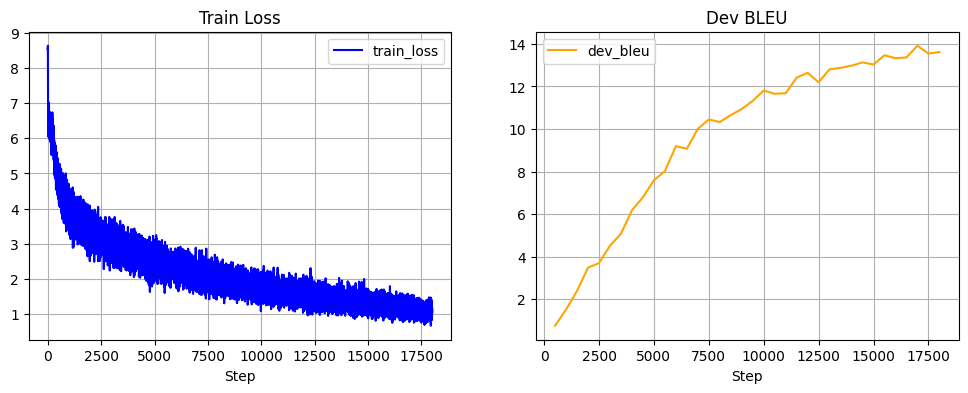

 90%|████████▉ | 17999/20000 [26:34<02:57, 11.28it/s]

Step 18000: avg_train_loss = 1.071, dev_bleu = 13.62
Best BLEU = 13.92, patience = 10
Early stopping triggered at step 18000. Best dev BLEU = 13.92
Training finished. Final dev BLEU = 13.92


In [14]:
for step in trange(1, total_steps+1):
    idx = np.random.randint(0, len(train_ru_np), size=batch_size)
    src_batch = ru_vocab.to_matrix(train_ru_np[idx]).to(device)
    tgt_batch = en_vocab.to_matrix(train_en_np[idx]).to(device)
    
    opt.zero_grad()
    loss_val = compute_loss(model, src_batch, tgt_batch)
    loss_val.backward()
    opt.step()
    
    cur_loss = loss_val.item()
    metrics['train_loss'].append((step, cur_loss))
    losses.append(cur_loss)

    if len(losses) > 500:
        losses = losses[-500:]
    # Каждые 500 шагов вычисляем BLEU и обновляем lr scheduler
    if step % 500 == 0:
        avg_loss = np.mean(losses)
        scheduler.step(avg_loss)
        
        current_bleu = compute_bleu(model, dev_inp, dev_out, use_sampling=True)
        metrics['dev_bleu'].append((step, current_bleu))
        
        # Проверяем условие ранней остановки на основе BLEU
        best_bleu, patience_counter, stop_flag = check_early_stop(current_bleu, best_bleu, patience_counter, patience=10)
        
        clear_output(True)
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.title("Train Loss")
        steps_loss, vals_loss = zip(*metrics['train_loss'])
        plt.plot(steps_loss, vals_loss, 'b-', label="train_loss")
        plt.xlabel("Step")
        plt.grid(True)
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.title("Dev BLEU")
        if metrics['dev_bleu']:
            steps_bleu, vals_bleu = zip(*metrics['dev_bleu'])
            plt.plot(steps_bleu, vals_bleu, 'orange', label="dev_bleu")
        plt.xlabel("Step")
        plt.grid(True)
        plt.legend()
        plt.show()
        
        print(f"Step {step}: avg_train_loss = {avg_loss:.3f}, dev_bleu = {current_bleu:.2f}")
        print(f"Best BLEU = {best_bleu:.2f}, patience = {patience_counter}")
        
        if stop_flag:
            print(f"Early stopping triggered at step {step}. Best dev BLEU = {best_bleu:.2f}")
            break

print(f"Training finished. Final dev BLEU = {best_bleu:.2f}")

In [15]:
compute_bleu(model, dev_inp, dev_out, use_sampling=True)

13.81153293990081

BLEU получился хуже, возможно потому что из-за early stopping не доучилась сеть, либо из-за темпаратурного семплирования, далее я попробую без него.

### Убираем семплирование

In [18]:
class BiLSTMAttModel(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, emb_dim=256, hid_dim=256, att_dim=256,
                 n_layers_enc=2, n_layers_dec=1, bidir=True):
        super().__init__()
        self.src_voc, self.tgt_voc = src_vocab, tgt_vocab
        self.emb_src = nn.Embedding(len(src_vocab), emb_dim)
        self.emb_tgt = nn.Embedding(len(tgt_vocab), emb_dim)
        self.bidir = bidir
        self.n_directions = 2 if bidir else 1

        self.encoder = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers_enc,
                               batch_first=True, bidirectional=bidir)
        self.attn = SimpleAttention(enc_size=hid_dim * self.n_directions,
                                    dec_size=hid_dim,
                                    hid_size=att_dim)
        self.init_dec = nn.Linear(hid_dim * self.n_directions, hid_dim)
        # Слой для приведения контекстного вектора к размерности декодера
        self.attn_proj_dec = nn.Linear(hid_dim * self.n_directions, hid_dim)
        # Декодер на основе LSTMCell
        self.decoder = nn.LSTMCell(emb_dim + hid_dim, hid_dim)
        self.lin_out = nn.Linear(hid_dim, len(tgt_vocab))

    def encode(self, src_batch):
        emb = self.emb_src(src_batch)
        enc_seq, _ = self.encoder(emb)
        lengths = (src_batch != self.src_voc.eos_ix).to(torch.int64).sum(dim=1).clamp(max=src_batch.shape[1] - 1)
        last = enc_seq[torch.arange(len(enc_seq)), lengths]
        dec_init = self.init_dec(last)
        mask = self.src_voc.compute_mask(src_batch)
        return enc_seq, dec_init, mask

    def decode_train(self, enc_seq, dec_init, src_mask, tgt_batch):
        bs, t_out = tgt_batch.shape
        h_t = dec_init
        c_t = torch.zeros_like(h_t)
        bos_onehot = F.one_hot(
            torch.full([bs], self.tgt_voc.bos_ix, dtype=torch.int64, device=enc_seq.device),
            num_classes=len(self.tgt_voc)
        ).float()
        bos_log = torch.log(bos_onehot + 1e-9)
        logits_seq = [bos_log]
        for i in range(t_out - 1):
            ctx, _ = self.attn(enc_seq, h_t, src_mask)
            ctx = self.attn_proj_dec(ctx)
            emb_out = self.emb_tgt(tgt_batch[:, i])
            inp_dec = torch.cat([ctx, emb_out], dim=-1)
            h_t, c_t = self.decoder(inp_dec, (h_t, c_t))
            logits_seq.append(self.lin_out(h_t))
        return torch.stack(logits_seq, dim=1)

    def forward(self, src_batch, tgt_batch):
        enc_seq, dec_init, mask_src = self.encode(src_batch)
        return self.decode_train(enc_seq, dec_init, mask_src, tgt_batch)

    @torch.no_grad()
    def decode_greedy(self, src_enc, dec_init, src_mask, max_len=100):
        """Жадный инференс: на каждом шаге выбирается токен с максимальной вероятностью."""
        bs = src_enc.shape[0]
        h_t = dec_init
        c_t = torch.zeros_like(dec_init)
        outputs = [torch.full([bs], self.tgt_voc.bos_ix, dtype=torch.int64, device=src_enc.device)]
        for _ in range(max_len):
            ctx, _ = self.attn(src_enc, h_t, src_mask)
            ctx = self.attn_proj_dec(ctx)
            emb_dec = self.emb_tgt(outputs[-1])
            inp_dec = torch.cat([ctx, emb_dec], dim=-1)
            h_t, c_t = self.decoder(inp_dec, (h_t, c_t))
            out_logit = self.lin_out(h_t)
            next_token = out_logit.argmax(dim=-1)
            outputs.append(next_token)
        return torch.stack(outputs, dim=1)

    @torch.no_grad()
    def decode_inference_sampling(self, src_enc, dec_init, src_mask, max_len=100, temperature=1.0):
        """
        Инференс с использованием температурного сэмплирования:
        На каждом шаге применяется softmax с делением на temperature,
        а следующий токен выбирается случайно (torch.multinomial).
        """
        bs = src_enc.shape[0]
        h_t = dec_init
        c_t = torch.zeros_like(dec_init)
        outputs = [torch.full([bs], self.tgt_voc.bos_ix, dtype=torch.int64, device=src_enc.device)]
        for _ in range(max_len):
            ctx, _ = self.attn(src_enc, h_t, src_mask)
            ctx = self.attn_proj_dec(ctx)
            emb_dec = self.emb_tgt(outputs[-1])
            inp_dec = torch.cat([ctx, emb_dec], dim=-1)
            h_t, c_t = self.decoder(inp_dec, (h_t, c_t))
            logits = self.lin_out(h_t)
            probs = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).squeeze(1)
            outputs.append(next_token)
        return torch.stack(outputs, dim=1)

    @torch.no_grad()
    def translate_lines(self, src_lines, use_sampling=True, temperature=1.0, max_len=100):
        src_mat = self.src_voc.to_matrix(src_lines).to(next(self.parameters()).device)
        enc_seq, dec_init, mask_src = self.encode(src_mat)
        if use_sampling:
            out_seq = self.decode_inference_sampling(enc_seq, dec_init, mask_src, max_len=max_len, temperature=temperature)
        else:
            out_seq = self.decode_greedy(enc_seq, dec_init, mask_src, max_len=max_len)
        return self.tgt_voc.to_lines(out_seq.cpu().numpy())

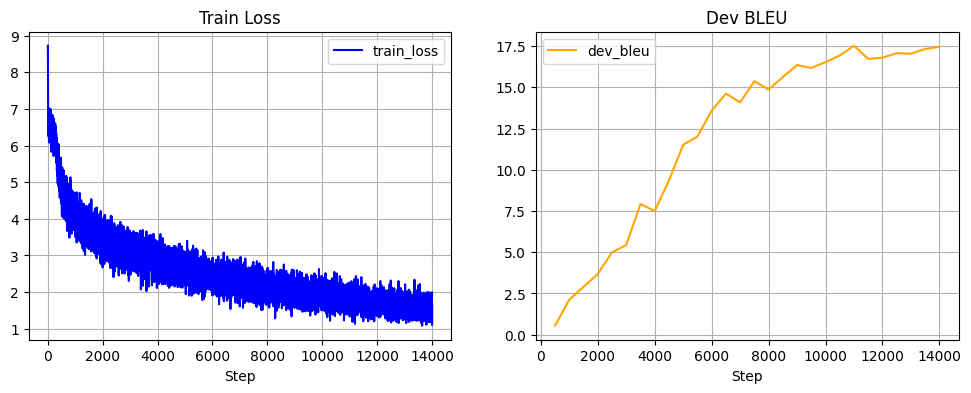

 70%|██████▉   | 13999/20000 [21:56<09:24, 10.64it/s]

Step 14000: avg_train_loss = 1.549, dev_bleu = 17.46
Best BLEU = 17.52, patience = 10
Early stopping triggered at step 14000. Best dev BLEU = 17.52
Training finished. Final dev BLEU = 17.52


In [19]:
model = BiLSTMAttModel(ru_vocab, en_vocab, emb_dim=256, hid_dim=256, att_dim=256,
                         n_layers_enc=2, n_layers_dec=1, bidir=True).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=6)

metrics = {'train_loss': [], 'dev_bleu': []}

losses = []

best_bleu = 0.0
patience_counter = 0


for step in trange(1, total_steps+1):
    idx = np.random.randint(0, len(train_ru_np), size=batch_size)
    src_batch = ru_vocab.to_matrix(train_ru_np[idx]).to(device)
    tgt_batch = en_vocab.to_matrix(train_en_np[idx]).to(device)
    
    opt.zero_grad()
    loss_val = compute_loss(model, src_batch, tgt_batch)
    loss_val.backward()
    opt.step()
    
    cur_loss = loss_val.item()
    metrics['train_loss'].append((step, cur_loss))
    losses.append(cur_loss)

    if len(losses) > 500:
        losses = losses[-500:]
    # Каждые 500 шагов вычисляем BLEU и обновляем lr scheduler
    if step % 500 == 0:
        avg_loss = np.mean(losses)
        scheduler.step(avg_loss)
        
        current_bleu = compute_bleu(model, dev_inp, dev_out, use_sampling=False)
        metrics['dev_bleu'].append((step, current_bleu))
        
        # Проверяем условие ранней остановки на основе BLEU
        best_bleu, patience_counter, stop_flag = check_early_stop(current_bleu, best_bleu, patience_counter, patience=10)
        
        clear_output(True)
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.title("Train Loss")
        steps_loss, vals_loss = zip(*metrics['train_loss'])
        plt.plot(steps_loss, vals_loss, 'b-', label="train_loss")
        plt.xlabel("Step")
        plt.grid(True)
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.title("Dev BLEU")
        if metrics['dev_bleu']:
            steps_bleu, vals_bleu = zip(*metrics['dev_bleu'])
            plt.plot(steps_bleu, vals_bleu, 'orange', label="dev_bleu")
        plt.xlabel("Step")
        plt.grid(True)
        plt.legend()
        plt.show()
        
        print(f"Step {step}: avg_train_loss = {avg_loss:.3f}, dev_bleu = {current_bleu:.2f}")
        print(f"Best BLEU = {best_bleu:.2f}, patience = {patience_counter}")
        
        if stop_flag:
            print(f"Early stopping triggered at step {step}. Best dev BLEU = {best_bleu:.2f}")
            break

print(f"Training finished. Final dev BLEU = {best_bleu:.2f}")

In [20]:
compute_bleu(model, dev_inp, dev_out, use_sampling=False)

17.456715239080488

Стало лучше, но также проверю без early stopping and scheduler

### убираю early stopping and scheduler

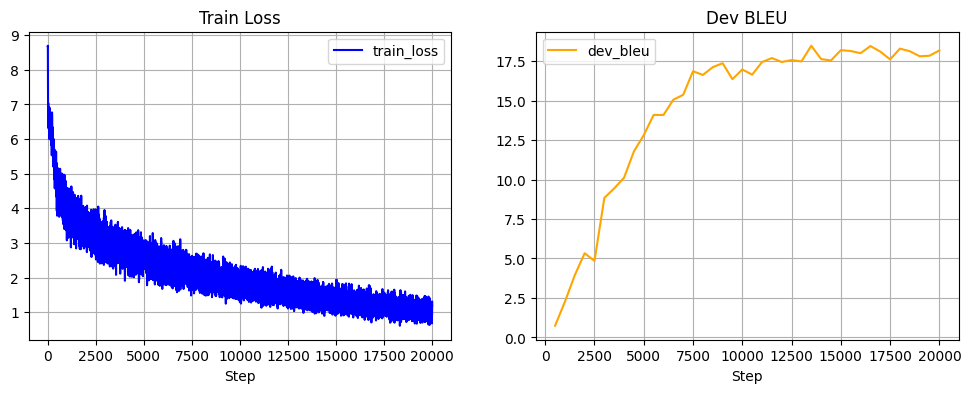

100%|██████████| 20000/20000 [30:36<00:00, 10.89it/s]

Step 20000: avg_train_loss = 1.031, dev_bleu = 18.17
Best BLEU so far = 18.47
Training finished. Final dev BLEU = 18.47


In [21]:
model = BiLSTMAttModel(ru_vocab, en_vocab, emb_dim=256, hid_dim=256, att_dim=256,
                         n_layers_enc=2, n_layers_dec=1, bidir=True).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

metrics = {'train_loss': [], 'dev_bleu': []}
losses = []

best_bleu = 0.0  # Эта переменная теперь просто для вывода лучшего BLEU

for step in trange(1, total_steps+1):
    idx = np.random.randint(0, len(train_ru_np), size=batch_size)
    src_batch = ru_vocab.to_matrix(train_ru_np[idx]).to(device)
    tgt_batch = en_vocab.to_matrix(train_en_np[idx]).to(device)
    
    opt.zero_grad()
    loss_val = compute_loss(model, src_batch, tgt_batch)
    loss_val.backward()
    opt.step()
    
    cur_loss = loss_val.item()
    metrics['train_loss'].append((step, cur_loss))
    losses.append(cur_loss)
    
    # Ограничиваем список последних значений до 500
    if len(losses) > 500:
        losses = losses[-500:]
    
    # Каждые 500 шагов вычисляем BLEU на dev-наборе и отрисовываем графики
    if step % 500 == 0:
        avg_loss = np.mean(losses)
        current_bleu = compute_bleu(model, dev_inp, dev_out, use_sampling=False)
        metrics['dev_bleu'].append((step, current_bleu))
        
        # Обновляем best_bleu (без логики early stopping)
        if current_bleu > best_bleu:
            best_bleu = current_bleu
        
        clear_output(True)
        plt.figure(figsize=(12, 4))
        
        # График train_loss
        plt.subplot(1, 2, 1)
        plt.title("Train Loss")
        steps_loss, vals_loss = zip(*metrics['train_loss'])
        plt.plot(steps_loss, vals_loss, 'b-', label="train_loss")
        plt.xlabel("Step")
        plt.grid(True)
        plt.legend()
        
        # График dev_bleu
        plt.subplot(1, 2, 2)
        plt.title("Dev BLEU")
        if metrics['dev_bleu']:
            steps_bleu, vals_bleu = zip(*metrics['dev_bleu'])
            plt.plot(steps_bleu, vals_bleu, 'orange', linestyle='-', label="dev_bleu")
        plt.xlabel("Step")
        plt.grid(True)
        plt.legend()
        plt.show()
        
        print(f"Step {step}: avg_train_loss = {avg_loss:.3f}, dev_bleu = {current_bleu:.2f}")
        print(f"Best BLEU so far = {best_bleu:.2f}")

print(f"Training finished. Final dev BLEU = {best_bleu:.2f}")


In [22]:
compute_bleu(model, dev_inp, dev_out, use_sampling=False)

18.17350681515441

### Итог
Жадный выбор токенов демонстрирует чуть лучшие показатели, чем температурное сэмплирование, что логично, так как генерация получается менее вариативной. Кроме того, из-за применения ранней остановки сеть не доучивалась, для прогона без early stopping и без scheduler вероятно нужно было больше эпох, поэтому модель вероятно также не доучилась. Метрики получились хуже чем на лекции, но допрогнать не успеваю из-за дедлайна.